# R-peak guided ML2: P/T beat segmentation

One beat starts at a Pan-Tompkins R peak. Each beat has 120 samples before R and 240 after R. The model learns only Background, P, and T. QRS goes to Background because Pan-Tompkins already finds R.


In [17]:
# Run once if packages are missing.
%pip install -q wfdb scipy scikit-learn torch matplotlib pandas


Note: you may need to restart the kernel to use updated packages.


In [43]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import wfdb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'PQRST_mapping' else Path.cwd().resolve()
DATA_DIR = REPO_ROOT / 'physionet.org/files/qtdb/1.0.0'
assert DATA_DIR.exists(), f'No QTDB data here: {DATA_DIR}'

PRE = 120
POST = 240
BEAT_LENGTH = PRE + POST
BATCH_SIZE = 64
NUM_EPOCHS = 30
MODEL_SAVE_PATH = 'best_ml2_rpeak_guided.pth'
NORMALIZATION_SAVE_PATH = 'best_ml2_rpeak_guided_normalization.npz'

records = sorted({path.stem for path in DATA_DIR.glob('*.dat')})
print(f'Records: {len(records)} | beat size: {BEAT_LENGTH} samples')


Records: 105 | beat size: 360 samples


In [44]:
def generate_labels(ecg, pu0):
    """QTDB pu0 labels: 0 background, 1 P, 2 QRS, 3 T."""
    labels = np.zeros(len(ecg), dtype=np.int64)
    start, wave_kind = None, None
    for sample, symbol in zip(pu0.sample, pu0.symbol):
        if symbol == '(':
            start, wave_kind = sample, None
        elif symbol == 'p':
            wave_kind = 1
        elif symbol == 'N':
            wave_kind = 2
        elif symbol == 't':
            wave_kind = 3
        elif symbol == ')' and start is not None and wave_kind is not None:
            labels[start:sample + 1] = wave_kind
            start, wave_kind = None, None
    return labels

def to_pt_labels(labels):
    """Make 3 classes: background=0, P=1, T=2. QRS becomes background."""
    labels = labels.copy()
    labels[labels == 2] = 0
    labels[labels == 3] = 2
    return labels

def pan_tompkins_r_peaks(ecg, fs, lowcut=5.0, highcut=18.0):
    """Small Pan-Tompkins chain. Output is ECG R locations."""
    nyquist = fs / 2
    sos = butter(3, [lowcut / nyquist, highcut / nyquist], btype='bandpass', output='sos')
    bandpassed = sosfiltfilt(sos, ecg)
    derivative = np.convolve(bandpassed, np.array([-1, -2, 0, 2, 1]) * fs / 8, mode='same')
    integrated = np.convolve(derivative ** 2, np.ones(max(1, round(0.150 * fs))) / max(1, round(0.150 * fs)), mode='same')
    candidates, _ = find_peaks(integrated, distance=max(1, round(0.20 * fs)))
    boot = candidates[candidates < min(len(ecg), round(2 * fs))]
    boot = boot if len(boot) else candidates
    spki = np.percentile(integrated[boot], 90) if len(boot) else 0.0
    npki = np.percentile(integrated[boot], 25) if len(boot) else 0.0
    accepted = []
    for peak in candidates:
        threshold = npki + 0.25 * (spki - npki)
        if integrated[peak] >= threshold:
            accepted.append(peak)
            spki = 0.125 * integrated[peak] + 0.875 * spki
        else:
            npki = 0.125 * integrated[peak] + 0.875 * npki
    search = round(0.10 * fs)
    refined = []
    for peak in accepted:
        left, right = max(0, peak - search), min(len(ecg), peak + search + 1)
        refined.append(left + np.argmax(ecg[left:right]))
    return np.unique(np.asarray(refined, dtype=int))


In [45]:
def create_r_centered_beats(ecg, labels, r_peaks, pre=PRE, post=POST):
    X, Y, kept_r = [], [], []
    for r in r_peaks:
        left, right = r - pre, r + post
        if left < 0 or right > len(ecg):
            continue
        X.append(ecg[left:right])
        Y.append(labels[left:right])
        kept_r.append(r)
    return np.asarray(X, dtype=np.float32), np.asarray(Y, dtype=np.int64), np.asarray(kept_r, dtype=int)

X_parts, Y_parts, record_ids, r_peak_parts = [], [], [], []
skipped = []
for record_name in records:
    path = str(DATA_DIR / record_name)
    try:
        record = wfdb.rdrecord(path)
        ecg = record.p_signal[:, 0].astype(np.float32)
        labels = to_pt_labels(generate_labels(ecg, wfdb.rdann(path, 'pu0')))
        r_peaks = pan_tompkins_r_peaks(ecg, float(record.fs))
        X, Y, kept_r = create_r_centered_beats(ecg, labels, r_peaks)
        if not len(X):
            raise ValueError('No full R-centred beats')
        X_parts.append(X); Y_parts.append(Y); r_peak_parts.append(kept_r)
        record_ids.extend([record_name] * len(X))
        print(f'{record_name}: {len(X)} beats')
    except Exception as error:
        skipped.append((record_name, str(error)))
        print(f'Skipped {record_name}: {error}')

X_total = np.concatenate(X_parts)
Y_total = np.concatenate(Y_parts)
r_peaks_total = np.concatenate(r_peak_parts)
record_ids = np.asarray(record_ids)
print(f'\nBeats: {len(X_total)} | shape: {X_total.shape} | class counts: {np.bincount(Y_total.ravel(), minlength=3)}')
if skipped: print(f'Skipped records: {len(skipped)}')


sel100: 1133 beats
sel102: 1087 beats
sel103: 1047 beats
sel104: 1092 beats
sel114: 339 beats
sel116: 1184 beats
sel117: 765 beats
sel123: 753 beats
sel14046: 1256 beats
sel14157: 1079 beats
sel14172: 662 beats
sel15814: 1023 beats
sel16265: 1030 beats
sel16272: 849 beats
sel16273: 1109 beats
sel16420: 1062 beats
sel16483: 1084 beats
sel16539: 921 beats
sel16773: 1007 beats
sel16786: 924 beats
sel16795: 760 beats
sel17152: 1625 beats
sel17453: 1046 beats
sel213: 1638 beats
sel221: 1234 beats
sel223: 1302 beats
sel230: 1076 beats
sel231: 731 beats
sel232: 862 beats
sel233: 1525 beats
sel30: 1012 beats
sel301: 1350 beats
sel302: 1499 beats
sel306: 1038 beats
sel307: 852 beats
sel308: 1294 beats
sel31: 1086 beats
sel310: 2009 beats
sel32: 703 beats
sel33: 526 beats
sel34: 896 beats
sel35: 854 beats
sel36: 946 beats
sel37: 666 beats
sel38: 1560 beats
sel39: 1170 beats
sel40: 1067 beats
sel41: 1365 beats
sel42: 1246 beats
sel43: 1428 beats
sel44: 1303 beats
sel45: 970 beats
sel46: 856 beats

In [46]:
# Split by record. Same record never goes in both train and validation.
train_records, val_records = train_test_split(np.unique(record_ids), test_size=0.20, random_state=42, shuffle=True)
train_mask = np.isin(record_ids, train_records)
val_mask = np.isin(record_ids, val_records)

X_train, Y_train = X_total[train_mask], Y_total[train_mask]
X_val, Y_val = X_total[val_mask], Y_total[val_mask]
val_record_ids = record_ids[val_mask]

train_mean, train_std = X_train.mean(), X_train.std()
np.savez(NORMALIZATION_SAVE_PATH, train_mean=train_mean, train_std=train_std)
print(f'Saved training scale: {NORMALIZATION_SAVE_PATH}')
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std

train_dataset = TensorDataset(torch.tensor(X_train).unsqueeze(1), torch.tensor(Y_train))
val_dataset = TensorDataset(torch.tensor(X_val).unsqueeze(1), torch.tensor(Y_val))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_dataset)} beats from {len(train_records)} records')
print(f'Val:   {len(val_dataset)} beats from {len(val_records)} records')


Saved training scale: best_ml2_rpeak_guided_normalization.npz
Train: 88237 beats from 84 records
Val:   21673 beats from 21 records


In [47]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
        )
    def forward(self, x):
        return self.features(x)

class BiLSTMBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)
    def forward(self, x):
        return self.lstm(x)[0]

class RPeakGuidedML2(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.bilstm = BiLSTMBlock()
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        x = self.bilstm(x)
        return self.classifier(self.dropout(x))

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
model = RPeakGuidedML2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f'Device: {device} | model classes: 3')


Device: mps | model classes: 3


In [23]:
def run_epoch(model, loader, train=False):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for batch_ecg, batch_labels in loader:
            batch_ecg, batch_labels = batch_ecg.to(device), batch_labels.to(device)
            logits = model(batch_ecg).permute(0, 2, 1)
            loss = criterion(logits, batch_labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

train_losses, val_losses = [], []
best_val_loss, best_epoch = float('inf'), 0
for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(model, train_loader, train=True)
    val_loss = run_epoch(model, val_loader, train=False)
    train_losses.append(train_loss); val_losses.append(val_loss)
    print(f'Epoch {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')
    if val_loss < best_val_loss:
        best_val_loss, best_epoch = val_loss, epoch + 1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f'Best: epoch {best_epoch}, val loss {best_val_loss:.4f}; saved {MODEL_SAVE_PATH}')


Epoch 01/30: train 0.3695, val 0.2881
Epoch 02/30: train 0.2118, val 0.2452
Epoch 03/30: train 0.1950, val 0.2506
Epoch 04/30: train 0.1606, val 0.2246
Epoch 05/30: train 0.1520, val 0.2322
Epoch 06/30: train 0.1438, val 0.2343
Epoch 07/30: train 0.1391, val 0.2094
Epoch 08/30: train 0.1356, val 0.2089
Epoch 09/30: train 0.1317, val 0.2456
Epoch 10/30: train 0.1273, val 0.1998
Epoch 11/30: train 0.1247, val 0.2043
Epoch 12/30: train 0.1233, val 0.2080
Epoch 13/30: train 0.1207, val 0.2203
Epoch 14/30: train 0.1195, val 0.2183
Epoch 15/30: train 0.1174, val 0.1928
Epoch 16/30: train 0.1168, val 0.2186
Epoch 17/30: train 0.1148, val 0.2078
Epoch 18/30: train 0.1130, val 0.1928
Epoch 19/30: train 0.1131, val 0.2017
Epoch 20/30: train 0.1113, val 0.2020
Epoch 21/30: train 0.1093, val 0.1961
Epoch 22/30: train 0.1089, val 0.1926
Epoch 23/30: train 0.1081, val 0.2116
Epoch 24/30: train 0.1074, val 0.1979
Epoch 25/30: train 0.1060, val 0.2174
Epoch 26/30: train 0.1058, val 0.2086
Epoch 27/30:

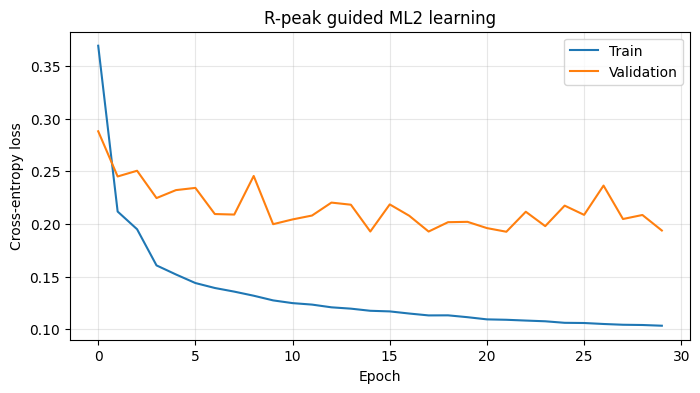

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.title('R-peak guided ML2 learning')
plt.grid(alpha=0.3); plt.legend(); plt.show()


In [37]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()
all_predictions, all_labels = [], []
with torch.no_grad():
    for batch_ecg, batch_labels in val_loader:
        predicted = model(batch_ecg.to(device)).argmax(dim=2).cpu().numpy()
        all_predictions.append(predicted)
        all_labels.append(batch_labels.numpy())
all_predictions = np.concatenate(all_predictions)
all_labels = np.concatenate(all_labels)

print(classification_report(all_labels.ravel(), all_predictions.ravel(),
                            labels=[0, 1, 2], target_names=['Background', 'P Wave', 'T Wave'], digits=4, zero_division=0))
p_f1, t_f1 = f1_score(all_labels.ravel(), all_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
macro_f1 = f1_score(all_labels.ravel(), all_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)
print(f'P F1: {p_f1:.4f} | T F1: {t_f1:.4f} | Macro F1: {macro_f1:.4f}')


              precision    recall  f1-score   support

  Background     0.9874    0.8076    0.8885   4970192
      P Wave     0.7118    0.9897    0.8281   1044867
      T Wave     0.7429    0.9496    0.8336   1787221

    accuracy                         0.8645   7802280
   macro avg     0.8140    0.9156    0.8501   7802280
weighted avg     0.8945    0.8645    0.8678   7802280

P F1: 0.8281 | T F1: 0.8336 | Macro F1: 0.8501


In [38]:
def first_and_last(labels, wave_class):
    points = np.flatnonzero(labels == wave_class)
    return (points[0], points[-1]) if len(points) else (np.nan, np.nan)

def boundary_error_ms(y_true, y_pred, fs=250.0):
    errors = {name: [] for name in ['P onset', 'P offset', 'T onset', 'T offset']}
    for truth, pred in zip(y_true, y_pred):
        for wave_class, onset_name, offset_name in [(1, 'P onset', 'P offset'), (2, 'T onset', 'T offset')]:
            true_on, true_off = first_and_last(truth, wave_class)
            pred_on, pred_off = first_and_last(pred, wave_class)
            if not np.isnan(true_on) and not np.isnan(pred_on):
                errors[onset_name].append(abs(pred_on - true_on) / fs * 1000)
                errors[offset_name].append(abs(pred_off - true_off) / fs * 1000)
    return {name: np.mean(values) if values else np.nan for name, values in errors.items()}

# QTDB records use 250 Hz. This is sample error turned into ms.
boundary_errors = boundary_error_ms(all_labels, all_predictions)
pd.Series(boundary_errors, name='mean absolute error (ms)').to_frame()


,mean absolute error (ms)
P onset,47.037726
P offset,142.909297
T onset,196.924827
T offset,94.567915


In [39]:
record_rows = []
for record_name in np.unique(val_record_ids):
    mask = val_record_ids == record_name
    record_rows.append({
        'record': record_name,
        'P F1': f1_score(all_labels[mask].ravel(), all_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(all_labels[mask].ravel(), all_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(all_labels[mask].ravel(), all_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0),
    })
record_df = pd.DataFrame(record_rows).sort_values('macro F1')
display(record_df.head(10))
worst_record = record_df.iloc[0]
print(f"Worst record: {worst_record['record']} | macro F1: {worst_record['macro F1']:.4f}")

comparison = pd.DataFrame([
    {'model': 'Old ML2 (fill from baseline run)', 'P F1': np.nan, 'T F1': np.nan, 'Macro F1': np.nan, 'Worst record': '', 'Boundary error (ms)': np.nan},
    {'model': 'R-centred ML2', 'P F1': p_f1, 'T F1': t_f1, 'Macro F1': macro_f1,
     'Worst record': worst_record['record'], 'Boundary error (ms)': np.nanmean(list(boundary_errors.values()))},
])
display(comparison)


,record,P F1,T F1,macro F1
10,sel41,0.448938,0.581832,0.536451
14,sele0112,0.518430,0.820266,0.737967
2,sel14172,0.740223,0.708652,0.747406
16,sele0203,0.780132,0.847993,0.770679
1,sel114,0.750660,0.734139,0.779249
9,sel39,0.729579,0.861044,0.802204
12,sel840,0.694417,0.904725,0.829881
20,sele0704,0.934070,0.709898,0.834849
6,sel30,0.842293,0.819701,0.853532
0,sel100,0.970893,0.756431,0.856174


Worst record: sel41 | macro F1: 0.5365


,model,P F1,T F1,Macro F1,Worst record,Boundary error (ms)
0,Old ML2 (fill from baseline run),NaN,NaN,NaN,,NaN
1,R-centred ML2,0.828092,0.833596,0.850052,sel41,120.359941


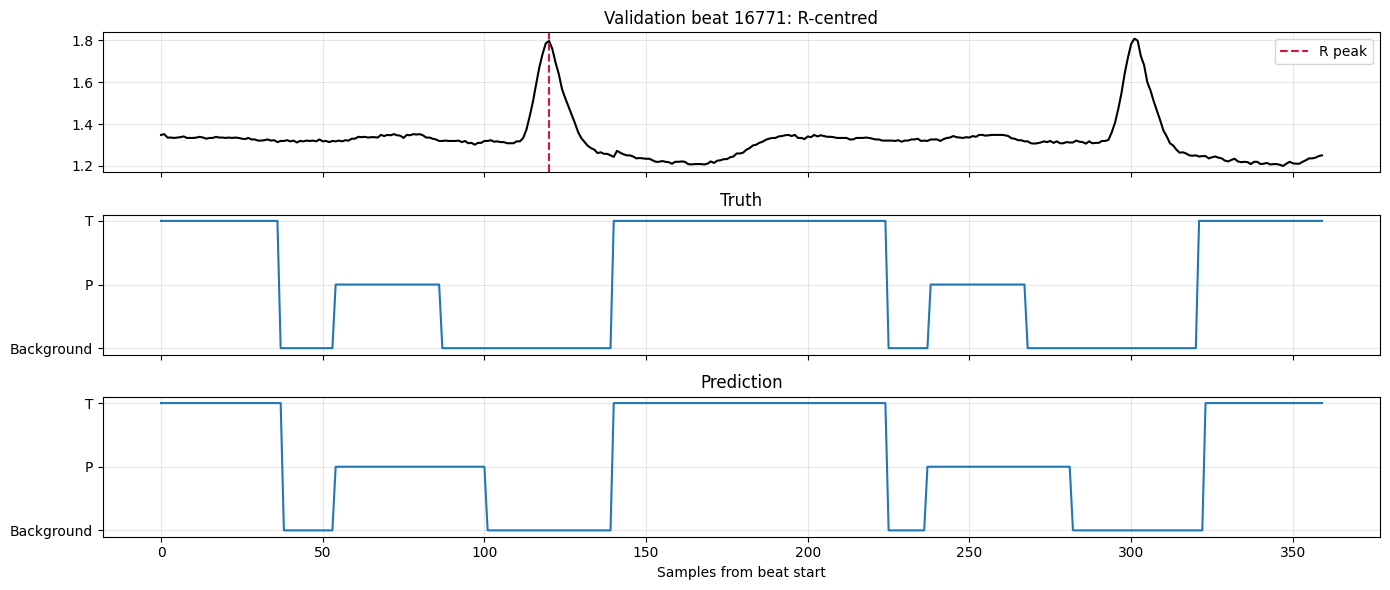

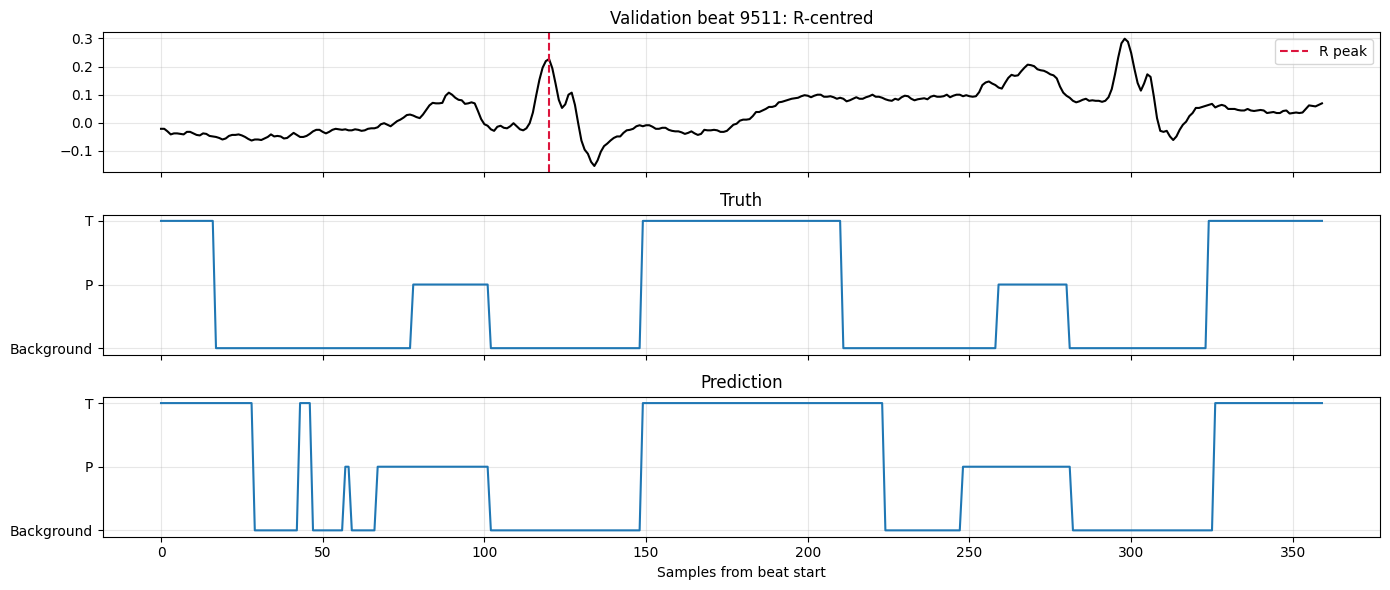

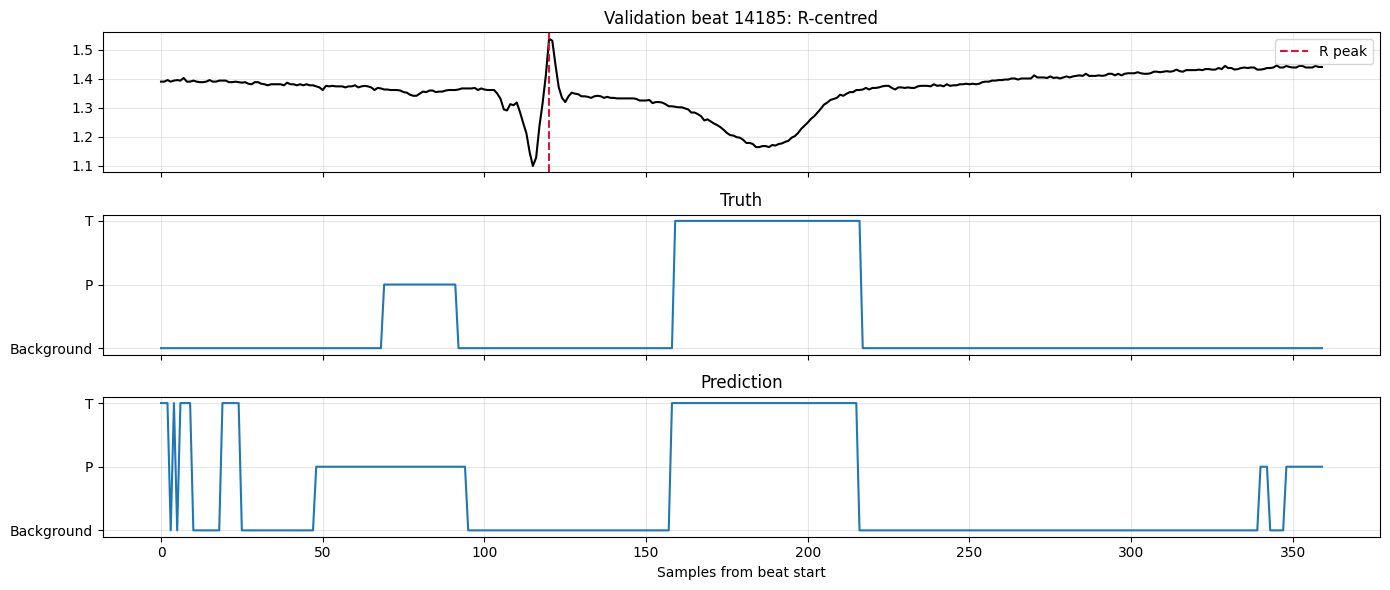

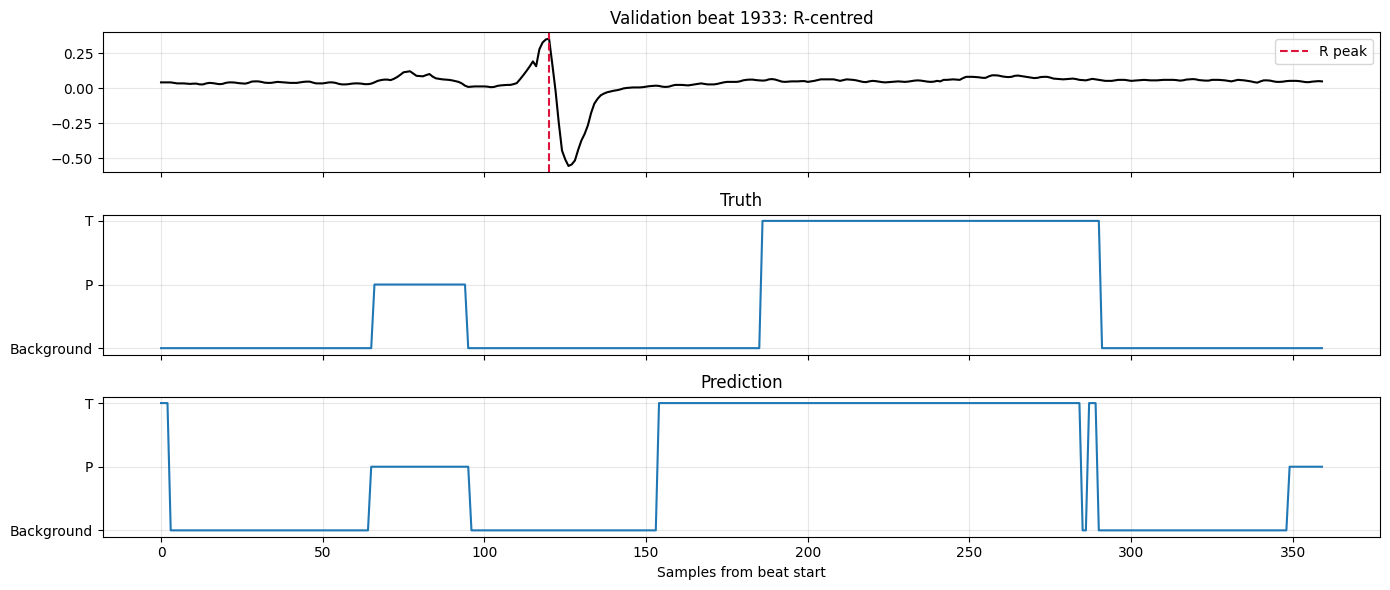

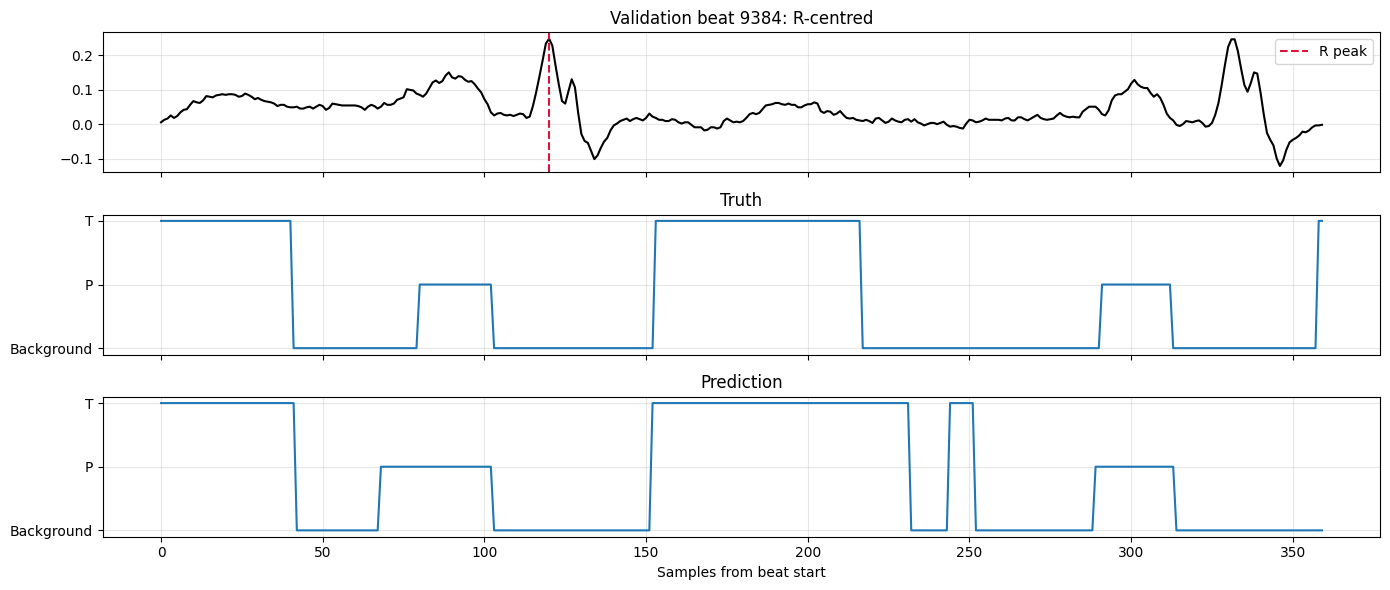

In [40]:
# Look at a few R-centred validation beats. R is at sample PRE.
rng = np.random.default_rng(42)
for idx in rng.choice(len(val_dataset), size=min(5, len(val_dataset)), replace=False):
    signal = val_dataset[idx][0].squeeze().numpy()
    truth, pred = all_labels[idx], all_predictions[idx]
    x = np.arange(BEAT_LENGTH)
    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(x, signal, color='black'); axes[0].axvline(PRE, color='crimson', ls='--', label='R peak'); axes[0].legend()
    axes[0].set_title(f'Validation beat {idx}: R-centred')
    axes[1].plot(x, truth); axes[1].set_yticks([0, 1, 2]); axes[1].set_yticklabels(['Background', 'P', 'T']); axes[1].set_title('Truth')
    axes[2].plot(x, pred); axes[2].set_yticks([0, 1, 2]); axes[2].set_yticklabels(['Background', 'P', 'T']); axes[2].set_title('Prediction')
    for ax in axes: ax.grid(alpha=0.3)
    axes[2].set_xlabel('Samples from beat start'); plt.tight_layout(); plt.show()


## LUDB external validation

LUDB is hold-out data. This test does not train or fine-tune. LUDB is 500 Hz, so signal and doctor labels go to 250 Hz before test. Lead II is used.


In [41]:
# LUDB external test. Run this only after the notebook train/data cells.
# LUDB is never used for training. It is a hold-out test.
from scipy.signal import resample_poly

LUDB_DIR = Path('physionet.org/files/ludb/1.0.1/data')
assert LUDB_DIR.exists(), f'Missing LUDB folder: {LUDB_DIR}'
assert 'train_mean' in globals() and 'train_std' in globals(), 'Run the QTDB training/data cells first.'

def ludb_labels_at_250(annotation, original_length):
    """LUDB annotation -> 0 Background, 1 P, 2 QRS, 3 T, at 250 Hz."""
    labels = np.zeros(round(original_length / 2), dtype=np.int64)
    start, kind = None, None
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if symbol == '(':
            start, kind = sample, None
        elif symbol == 'p':
            kind = 1
        elif symbol == 'N':
            kind = 2
        elif symbol == 't':
            kind = 3
        elif symbol == ')' and start is not None and kind is not None:
            left, right = round(start / 2), round(sample / 2)
            labels[left:right + 1] = kind
            start, kind = None, None
    return labels

def wave_intervals(labels, wave_class):
    mask = labels == wave_class
    edges = np.diff(np.r_[False, mask, False].astype(int))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1) - 1))

def boundary_errors_ms(y_true, y_pred, class_map, fs=250):
    errors = {f'{name} onset': [] for name in class_map.values()}
    errors.update({f'{name} offset': [] for name in class_map.values()})
    missed = {name: 0 for name in class_map.values()}
    for truth, pred in zip(y_true, y_pred):
        for wave_class, name in class_map.items():
            predicted = wave_intervals(pred, wave_class)
            for start, end in wave_intervals(truth, wave_class):
                overlaps = [max(0, min(end, p_end) - max(start, p_start) + 1)
                            for p_start, p_end in predicted]
                if not overlaps or max(overlaps) == 0:
                    missed[name] += 1
                    continue
                p_start, p_end = predicted[int(np.argmax(overlaps))]
                errors[f'{name} onset'].append(abs(p_start - start) / fs * 1000)
                errors[f'{name} offset'].append(abs(p_end - end) / fs * 1000)
    return {key: np.mean(value) if value else np.nan for key, value in errors.items()}, missed

ludb_x, ludb_y, ludb_record_ids = [], [], []
for header in sorted(LUDB_DIR.glob('*.hea')):
    record_name = header.stem
    path = str(header.with_suffix(''))
    record = wfdb.rdrecord(path)
    lead = record.sig_name.index('ii')  # QTDB MLII matches LUDB lead II.
    signal = resample_poly(record.p_signal[:, lead].astype(np.float32), up=1, down=2)
    annotation = wfdb.rdann(path, 'ii')
    labels = ludb_labels_at_250(annotation, len(record.p_signal))
    size = min(len(signal), len(labels))
    signal, labels = signal[:size], labels[:size]
    labels = to_pt_labels(labels)  # QRS is background for this model.
    r_peaks = pan_tompkins_r_peaks(signal, 250.0)
    X, Y, _ = create_r_centered_beats(signal, labels, r_peaks)
    if len(X):
        ludb_x.append(X); ludb_y.append(Y); ludb_record_ids.extend([record_name] * len(X))

X_ludb = np.concatenate(ludb_x)
Y_ludb = np.concatenate(ludb_y)
ludb_record_ids = np.asarray(ludb_record_ids)
X_ludb = (X_ludb - train_mean) / train_std
print(f'LUDB external test: {len(np.unique(ludb_record_ids))} records, {len(X_ludb)} R-centred beats')



LUDB external test: 200 records, 1904 R-centred beats


In [42]:
# Score saved QTDB model on LUDB. No fitting here.
model = RPeakGuidedML2().to(device)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        ludb_predictions.append(model(batch).argmax(dim=2).cpu().numpy())
ludb_predictions = np.concatenate(ludb_predictions)

p_f1_ludb, t_f1_ludb = f1_score(Y_ludb.ravel(), ludb_predictions.ravel(),
                                labels=[1, 2], average=None, zero_division=0)
macro_f1_ludb = f1_score(Y_ludb.ravel(), ludb_predictions.ravel(),
                         labels=[0, 1, 2], average='macro', zero_division=0)
errors_ludb, missed_ludb = boundary_errors_ms(Y_ludb, ludb_predictions, {1: 'P', 2: 'T'})
print(classification_report(Y_ludb.ravel(), ludb_predictions.ravel(),
                            labels=[0, 1, 2],
                            target_names=['Background', 'P Wave', 'T Wave'],
                            digits=4, zero_division=0))
print(f'LUDB P F1: {p_f1_ludb:.4f} | T F1: {t_f1_ludb:.4f} | Macro F1: {macro_f1_ludb:.4f}')
display(pd.Series(errors_ludb, name='boundary MAE (ms)').to_frame())
print('Missed true waves:', missed_ludb)

record_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    record_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
ludb_record_results = pd.DataFrame(record_rows).sort_values('macro F1')
display(ludb_record_results.head(10))



              precision    recall  f1-score   support

  Background     0.9202    0.9198    0.9200    509929
      P Wave     0.7533    0.8092    0.7802     75779
      T Wave     0.7684    0.7266    0.7469     99732

    accuracy                         0.8795    685440
   macro avg     0.8140    0.8185    0.8157    685440
weighted avg     0.8796    0.8795    0.8794    685440

LUDB P F1: 0.7802 | T F1: 0.7469 | Macro F1: 0.8157


,boundary MAE (ms)
P onset,11.102326
T onset,25.033363
P offset,10.079070
T offset,14.409378


Missed true waves: {'P': 133, 'T': 434}


,record,P F1,T F1,macro F1
11,109,0.000000,0.032541,0.302372
30,126,0.077033,0.000000,0.304523
38,133,0.026087,0.000000,0.305759
31,127,0.000000,0.000000,0.316642
3,101,0.000000,0.332514,0.375794
129,35,0.000000,0.333766,0.381046
13,110,0.000000,0.417707,0.429917
35,130,0.409692,0.000000,0.430662
187,88,0.000000,0.502242,0.439834
15,112,0.000000,0.489373,0.444465


## R2 — R-centred beats with weighted Focal Loss

R2 keeps R1 data, model, batch size, learning rate, and 30 epochs. Only loss changes. It uses the same weighted Focal Loss form as old ML2, now for 3 classes.


R2 class counts: [20805510  3785415  7174395]
R2 class weights: tensor([0.5089, 2.7972, 1.4759], device='mps:0')
Only R1 -> R2 change: CrossEntropy becomes weighted Focal Loss.
R2 epoch 01/30: train 0.1704, val 0.5708
R2 epoch 02/30: train 0.1505, val 0.0900
R2 epoch 03/30: train 0.0757, val 0.0910
R2 epoch 04/30: train 0.0665, val 0.0925
R2 epoch 05/30: train 0.0586, val 0.0799
R2 epoch 06/30: train 0.0540, val 0.0875
R2 epoch 07/30: train 0.0509, val 0.0752
R2 epoch 08/30: train 0.0486, val 0.0702
R2 epoch 09/30: train 0.0466, val 0.0732
R2 epoch 10/30: train 0.0449, val 0.0701
R2 epoch 11/30: train 0.0433, val 0.0730
R2 epoch 12/30: train 0.0415, val 0.0764
R2 epoch 13/30: train 0.0404, val 0.0578
R2 epoch 14/30: train 0.0408, val 0.0677
R2 epoch 15/30: train 0.0386, val 0.0679
R2 epoch 16/30: train 0.0383, val 0.0665
R2 epoch 17/30: train 0.0376, val 0.0609
R2 epoch 18/30: train 0.0370, val 0.0618
R2 epoch 19/30: train 0.0365, val 0.0603
R2 epoch 20/30: train 0.0354, val 0.0657
R2 

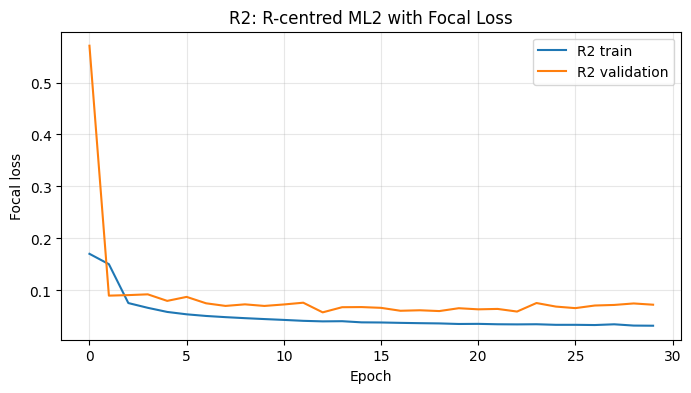

R2 QTDB: P F1 0.8281 | T F1 0.8336 | Macro F1 0.8501


,R2 boundary MAE (ms)
P onset,47.037726
P offset,142.909297
T onset,196.924827
T offset,94.567915


R2 LUDB: P F1 0.7195 | T F1 0.6897 | Macro F1 0.7560


,R2 boundary MAE (ms)
P onset,16.451658
T onset,21.995565
P offset,9.713479
T offset,34.075388


R2 missed true waves: {'P': 29, 'T': 43}


,record,P F1,T F1,macro F1
11,109,0.000000,0.169623,0.276123
5,103,0.000000,0.564179,0.367958
6,104,0.000000,0.472906,0.384327
3,101,0.000000,0.600836,0.396067
14,111,0.000000,0.483333,0.396843
30,126,0.283333,0.116086,0.400756
15,112,0.000000,0.604406,0.408425
31,127,0.000000,0.390144,0.410444
82,173,0.000000,0.629534,0.421086
33,129,0.000000,0.664562,0.462386


,experiment,P F1,T F1,Macro F1,Boundary MAE (ms)
0,R1: CrossEntropy,0.775433,0.749385,0.814811,15.128732
1,R2: weighted Focal Loss,0.719489,0.689713,0.756018,20.559023


In [36]:
import torch.nn.functional as F

# R2: only loss changes from R1.
R2_MODEL_SAVE_PATH = 'best_ml2_rpeak_guided_focal.pth'

class FocalLoss(nn.Module):
    """Same focal loss form used in ML2 baseline focal test."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()

# Same inverse-frequency weighting rule as old ML2. Classes: Background, P, T.
r2_class_counts = np.bincount(Y_train.ravel(), minlength=3)
r2_class_weights = torch.tensor(
    len(Y_train.ravel()) / (3 * r2_class_counts), dtype=torch.float32, device=device
)
focal_model = RPeakGuidedML2().to(device)
focal_criterion = FocalLoss(alpha=r2_class_weights, gamma=2.0)
focal_optimizer = torch.optim.Adam(focal_model.parameters(), lr=1e-3)

print('R2 class counts:', r2_class_counts)
print('R2 class weights:', r2_class_weights)
print('Only R1 -> R2 change: CrossEntropy becomes weighted Focal Loss.')

def run_r2_epoch(loader, train=False):
    focal_model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for batch_ecg, batch_labels in loader:
            batch_ecg, batch_labels = batch_ecg.to(device), batch_labels.to(device)
            logits = focal_model(batch_ecg).permute(0, 2, 1)
            loss = focal_criterion(logits, batch_labels)
            if train:
                focal_optimizer.zero_grad()
                loss.backward()
                focal_optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

r2_train_losses, r2_val_losses = [], []
r2_best_val_loss, r2_best_epoch = float('inf'), 0
for epoch in range(NUM_EPOCHS):
    train_loss = run_r2_epoch(train_loader, train=True)
    val_loss = run_r2_epoch(val_loader)
    r2_train_losses.append(train_loss)
    r2_val_losses.append(val_loss)
    print(f'R2 epoch {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')
    if val_loss < r2_best_val_loss:
        r2_best_val_loss, r2_best_epoch = val_loss, epoch + 1
        torch.save(focal_model.state_dict(), R2_MODEL_SAVE_PATH)
print(f'R2 best: epoch {r2_best_epoch}, val loss {r2_best_val_loss:.4f}; saved {R2_MODEL_SAVE_PATH}')

plt.figure(figsize=(8, 4))
plt.plot(r2_train_losses, label='R2 train')
plt.plot(r2_val_losses, label='R2 validation')
plt.xlabel('Epoch'); plt.ylabel('Focal loss'); plt.title('R2: R-centred ML2 with Focal Loss')
plt.grid(alpha=0.3); plt.legend(); plt.show()

# R2 QTDB hold-out score. Same record split as R1.
focal_model.load_state_dict(torch.load(R2_MODEL_SAVE_PATH, map_location=device))
focal_model.eval()
r2_predictions, r2_labels = [], []
with torch.no_grad():
    for batch_ecg, batch_labels in val_loader:
        r2_predictions.append(focal_model(batch_ecg.to(device)).argmax(dim=2).cpu().numpy())
        r2_labels.append(batch_labels.numpy())
r2_predictions, r2_labels = np.concatenate(r2_predictions), np.concatenate(r2_labels)
r2_p_f1, r2_t_f1 = f1_score(r2_labels.ravel(), r2_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r2_macro_f1 = f1_score(r2_labels.ravel(), r2_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)
r2_boundary_errors = boundary_error_ms(r2_labels, r2_predictions)
print(f'R2 QTDB: P F1 {r2_p_f1:.4f} | T F1 {r2_t_f1:.4f} | Macro F1 {r2_macro_f1:.4f}')
display(pd.Series(r2_boundary_errors, name='R2 boundary MAE (ms)').to_frame())

# R2 LUDB hold-out score. Run LUDB data and R1 score cells first.
assert 'X_ludb' in globals(), 'Run the LUDB data cell first.'
r1_ludb_metrics = ({
    'P F1': p_f1_ludb, 'T F1': t_f1_ludb, 'Macro F1': macro_f1_ludb,
    'Boundary MAE (ms)': np.nanmean(list(errors_ludb.values()))
} if 'p_f1_ludb' in globals() else None)

r2_ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        r2_ludb_predictions.append(focal_model(batch).argmax(dim=2).cpu().numpy())
r2_ludb_predictions = np.concatenate(r2_ludb_predictions)
r2_ludb_p_f1, r2_ludb_t_f1 = f1_score(Y_ludb.ravel(), r2_ludb_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r2_ludb_macro_f1 = f1_score(Y_ludb.ravel(), r2_ludb_predictions.ravel(), labels=[0, 1, 2], average='macro', zero_division=0)
r2_ludb_errors, r2_ludb_missed = boundary_errors_ms(Y_ludb, r2_ludb_predictions, {1: 'P', 2: 'T'})
print(f'R2 LUDB: P F1 {r2_ludb_p_f1:.4f} | T F1 {r2_ludb_t_f1:.4f} | Macro F1 {r2_ludb_macro_f1:.4f}')
display(pd.Series(r2_ludb_errors, name='R2 boundary MAE (ms)').to_frame())
print('R2 missed true waves:', r2_ludb_missed)

r2_ludb_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    r2_ludb_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), r2_ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), r2_ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), r2_ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
display(pd.DataFrame(r2_ludb_rows).sort_values('macro F1').head(10))

r2_ludb_metrics = {'P F1': r2_ludb_p_f1, 'T F1': r2_ludb_t_f1,
                   'Macro F1': r2_ludb_macro_f1,
                   'Boundary MAE (ms)': np.nanmean(list(r2_ludb_errors.values()))}
comparison_rows = []
if r1_ludb_metrics is not None:
    comparison_rows.append({'experiment': 'R1: CrossEntropy', **r1_ludb_metrics})
comparison_rows.append({'experiment': 'R2: weighted Focal Loss', **r2_ludb_metrics})
display(pd.DataFrame(comparison_rows))


## R3 — R-centred beats with unweighted Focal Loss

R3 keeps R1 model, data, batch size, learning rate, and epochs. It uses Focal Loss with gamma 2 but no class weights.


R3 change from R1: CrossEntropy -> unweighted Focal Loss only.
R3 epoch 01/30: train 0.1550, val 0.1038
R3 epoch 02/30: train 0.0757, val 0.0738
R3 epoch 03/30: train 0.0605, val 0.0752
R3 epoch 04/30: train 0.0532, val 0.0767
R3 epoch 05/30: train 0.0496, val 0.0695
R3 epoch 06/30: train 0.0457, val 0.0651
R3 epoch 07/30: train 0.0447, val 0.0764
R3 epoch 08/30: train 0.0421, val 0.0642
R3 epoch 09/30: train 0.0409, val 0.0650
R3 epoch 10/30: train 0.0393, val 0.0607
R3 epoch 11/30: train 0.0383, val 0.0700
R3 epoch 12/30: train 0.0390, val 0.0694
R3 epoch 13/30: train 0.0370, val 0.0668
R3 epoch 14/30: train 0.0367, val 0.0744
R3 epoch 15/30: train 0.0355, val 0.0589
R3 epoch 16/30: train 0.0351, val 0.0610
R3 epoch 17/30: train 0.0347, val 0.0726
R3 epoch 18/30: train 0.0346, val 0.0658
R3 epoch 19/30: train 0.0339, val 0.0647
R3 epoch 20/30: train 0.0334, val 0.0569
R3 epoch 21/30: train 0.0329, val 0.0623
R3 epoch 22/30: train 0.0325, val 0.0677
R3 epoch 23/30: train 0.0326, val 0

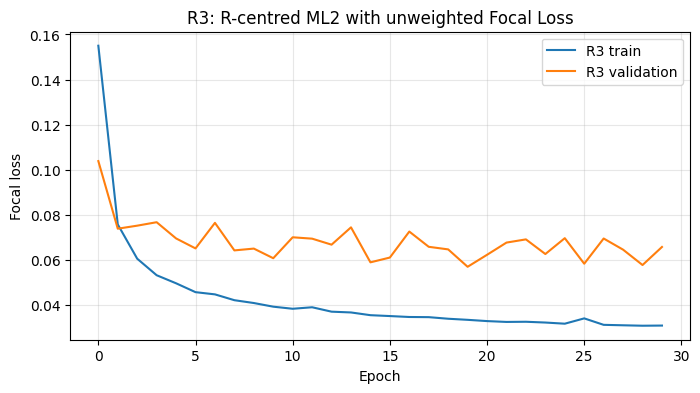

R3 QTDB: P F1 0.8941 | T F1 0.8709 | Macro F1 0.9013


,R3 boundary MAE (ms)
P onset,34.126431
P offset,65.923218
T onset,109.357377
T offset,67.187127


R3 LUDB: P F1 0.7866 | T F1 0.7341 | Macro F1 0.8134


,R3 boundary MAE (ms)
P onset,10.413846
T onset,26.200378
P offset,10.733846
T offset,15.122873


R3 missed true waves: {'P': 113, 'T': 536}


,record,P F1,T F1,macro F1
11,109,0.000000,0.033058,0.303963
31,127,0.000000,0.000000,0.313898
6,104,0.000000,0.113208,0.334631
3,101,0.000000,0.270079,0.356882
35,130,0.250712,0.006536,0.382046
30,126,0.287834,0.000000,0.383868
129,35,0.000000,0.344194,0.386042
38,133,0.342105,0.000000,0.412289
13,110,0.000000,0.427570,0.435569
15,112,0.000000,0.535065,0.459529


,experiment,P F1,T F1,Macro F1,Boundary MAE (ms)
0,R1: CrossEntropy,0.775433,0.749385,0.814811,15.128732
1,R2: weighted Focal Loss,0.719489,0.689713,0.756018,20.559023
2,R3: unweighted Focal Loss,0.786604,0.734083,0.813415,15.617736


In [48]:
# R3: standard unweighted Focal Loss. No alpha / no class weights.
R3_MODEL_SAVE_PATH = 'best_ml2_rpeak_guided_focal_unweighted.pth'

class UnweightedFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()

r3_model = RPeakGuidedML2().to(device)
r3_criterion = UnweightedFocalLoss(gamma=2.0)
r3_optimizer = torch.optim.Adam(r3_model.parameters(), lr=1e-3)
print('R3 change from R1: CrossEntropy -> unweighted Focal Loss only.')

def run_r3_epoch(loader, train=False):
    r3_model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for batch_ecg, batch_labels in loader:
            batch_ecg, batch_labels = batch_ecg.to(device), batch_labels.to(device)
            logits = r3_model(batch_ecg).permute(0, 2, 1)
            loss = r3_criterion(logits, batch_labels)
            if train:
                r3_optimizer.zero_grad()
                loss.backward()
                r3_optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

r3_train_losses, r3_val_losses = [], []
r3_best_val_loss, r3_best_epoch = float('inf'), 0
for epoch in range(NUM_EPOCHS):
    train_loss = run_r3_epoch(train_loader, train=True)
    val_loss = run_r3_epoch(val_loader)
    r3_train_losses.append(train_loss)
    r3_val_losses.append(val_loss)
    print(f'R3 epoch {epoch + 1:02d}/{NUM_EPOCHS}: train {train_loss:.4f}, val {val_loss:.4f}')
    if val_loss < r3_best_val_loss:
        r3_best_val_loss, r3_best_epoch = val_loss, epoch + 1
        torch.save(r3_model.state_dict(), R3_MODEL_SAVE_PATH)
print(f'R3 best: epoch {r3_best_epoch}, val loss {r3_best_val_loss:.4f}; saved {R3_MODEL_SAVE_PATH}')

plt.figure(figsize=(8, 4))
plt.plot(r3_train_losses, label='R3 train')
plt.plot(r3_val_losses, label='R3 validation')
plt.xlabel('Epoch'); plt.ylabel('Focal loss'); plt.title('R3: R-centred ML2 with unweighted Focal Loss')
plt.grid(alpha=0.3); plt.legend(); plt.show()

# R3 QTDB hold-out score. Same records as R1 and R2.
r3_model.load_state_dict(torch.load(R3_MODEL_SAVE_PATH, map_location=device))
r3_model.eval()
r3_predictions, r3_labels = [], []
with torch.no_grad():
    for batch_ecg, batch_labels in val_loader:
        r3_predictions.append(r3_model(batch_ecg.to(device)).argmax(dim=2).cpu().numpy())
        r3_labels.append(batch_labels.numpy())
r3_predictions, r3_labels = np.concatenate(r3_predictions), np.concatenate(r3_labels)
r3_p_f1, r3_t_f1 = f1_score(r3_labels.ravel(), r3_predictions.ravel(),
                            labels=[1, 2], average=None, zero_division=0)
r3_macro_f1 = f1_score(r3_labels.ravel(), r3_predictions.ravel(),
                       labels=[0, 1, 2], average='macro', zero_division=0)
r3_boundary_errors = boundary_error_ms(r3_labels, r3_predictions)
print(f'R3 QTDB: P F1 {r3_p_f1:.4f} | T F1 {r3_t_f1:.4f} | Macro F1 {r3_macro_f1:.4f}')
display(pd.Series(r3_boundary_errors, name='R3 boundary MAE (ms)').to_frame())

# R3 LUDB hold-out score. Run LUDB data and R1 score cells first.
assert 'X_ludb' in globals(), 'Run the LUDB data cell first.'
if 'r1_ludb_metrics' not in globals() and 'p_f1_ludb' in globals():
    r1_ludb_metrics = {
        'P F1': p_f1_ludb, 'T F1': t_f1_ludb, 'Macro F1': macro_f1_ludb,
        'Boundary MAE (ms)': np.nanmean(list(errors_ludb.values()))
    }

r3_ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        r3_ludb_predictions.append(r3_model(batch).argmax(dim=2).cpu().numpy())
r3_ludb_predictions = np.concatenate(r3_ludb_predictions)
r3_ludb_p_f1, r3_ludb_t_f1 = f1_score(Y_ludb.ravel(), r3_ludb_predictions.ravel(),
                                      labels=[1, 2], average=None, zero_division=0)
r3_ludb_macro_f1 = f1_score(Y_ludb.ravel(), r3_ludb_predictions.ravel(),
                            labels=[0, 1, 2], average='macro', zero_division=0)
r3_ludb_errors, r3_ludb_missed = boundary_errors_ms(Y_ludb, r3_ludb_predictions, {1: 'P', 2: 'T'})
print(f'R3 LUDB: P F1 {r3_ludb_p_f1:.4f} | T F1 {r3_ludb_t_f1:.4f} | Macro F1 {r3_ludb_macro_f1:.4f}')
display(pd.Series(r3_ludb_errors, name='R3 boundary MAE (ms)').to_frame())
print('R3 missed true waves:', r3_ludb_missed)

r3_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    r3_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), r3_ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), r3_ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), r3_ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
display(pd.DataFrame(r3_rows).sort_values('macro F1').head(10))

r3_ludb_metrics = {'P F1': r3_ludb_p_f1, 'T F1': r3_ludb_t_f1,
                   'Macro F1': r3_ludb_macro_f1,
                   'Boundary MAE (ms)': np.nanmean(list(r3_ludb_errors.values()))}
comparison_rows = []
if 'r1_ludb_metrics' in globals():
    comparison_rows.append({'experiment': 'R1: CrossEntropy', **r1_ludb_metrics})
if 'r2_ludb_metrics' in globals():
    comparison_rows.append({'experiment': 'R2: weighted Focal Loss', **r2_ludb_metrics})
comparison_rows.append({'experiment': 'R3: unweighted Focal Loss', **r3_ludb_metrics})
display(pd.DataFrame(comparison_rows))


## R4 — frozen R1 with R-aware T decoder

R4 does not train a new model. It uses R1 softmax scores. P is only allowed before R. One T area is picked after R. The T score limit is picked on QTDB validation only, then locked for LUDB.


In [49]:
# R4: frozen R1 model + physiology-aware decoder. No LUDB tuning.
R4_MODEL_SAVE_PATH = MODEL_SAVE_PATH
R4_T_START = PRE + 5
R4_T_MIN_LENGTH = 4
R4_T_THRESHOLDS = np.arange(0.10, 0.76, 0.05)

def r4_intervals(labels, wave_class):
    mask = labels == wave_class
    edges = np.diff(np.r_[False, mask, False].astype(int))
    return list(zip(np.flatnonzero(edges == 1), np.flatnonzero(edges == -1) - 1))

def r4_missed_waves(y_true, y_pred, wave_class):
    missed = 0
    for truth, pred in zip(y_true, y_pred):
        predicted = r4_intervals(pred, wave_class)
        for start, end in r4_intervals(truth, wave_class):
            if not any(max(0, min(end, p_end) - max(start, p_start) + 1) > 0
                       for p_start, p_end in predicted):
                missed += 1
    return missed

def r4_decode(probabilities, t_threshold, t_start=R4_T_START, min_length=R4_T_MIN_LENGTH):
    """Keep P before R. Pick one strongest valid T area after R."""
    decoded = probabilities.argmax(axis=2).astype(np.int64)
    for beat_idx, probs in enumerate(probabilities):
        # P after R and every raw T label are not physiologic output.
        decoded[beat_idx, PRE:] = np.where(decoded[beat_idx, PRE:] == 1, 0, decoded[beat_idx, PRE:])
        decoded[beat_idx, decoded[beat_idx] == 2] = 0

        t_score = probs[:, 2]
        active = np.zeros(len(t_score), dtype=bool)
        active[t_start:] = t_score[t_start:] >= t_threshold
        edges = np.diff(np.r_[False, active, False].astype(int))
        starts = np.flatnonzero(edges == 1)
        ends = np.flatnonzero(edges == -1) - 1
        choices = [(start, end) for start, end in zip(starts, ends) if end - start + 1 >= min_length]
        if choices:
            start, end = max(choices, key=lambda part: t_score[part[0]:part[1] + 1].sum())
            decoded[beat_idx, start:end + 1] = 2
    return decoded

def r4_probabilities(model_to_score, loader):
    values = []
    model_to_score.eval()
    with torch.no_grad():
        for batch_ecg, _ in loader:
            logits = model_to_score(batch_ecg.to(device))
            values.append(torch.softmax(logits, dim=2).cpu().numpy())
    return np.concatenate(values)

# Tune only on QTDB validation records. LUDB labels are not read here.
r4_model = RPeakGuidedML2().to(device)
r4_model.load_state_dict(torch.load(R4_MODEL_SAVE_PATH, map_location=device))
r4_val_probabilities = r4_probabilities(r4_model, val_loader)
r4_grid_rows = []
for threshold in R4_T_THRESHOLDS:
    prediction = r4_decode(r4_val_probabilities, threshold)
    r4_grid_rows.append({
        'T threshold': threshold,
        'P F1': f1_score(Y_val.ravel(), prediction.ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_val.ravel(), prediction.ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_val.ravel(), prediction.ravel(), labels=[0, 1, 2], average='macro', zero_division=0),
        'missed T': r4_missed_waves(Y_val, prediction, 2),
    })
r4_grid = pd.DataFrame(r4_grid_rows).sort_values(['T F1', 'missed T'], ascending=[False, True])
R4_T_THRESHOLD = float(r4_grid.iloc[0]['T threshold'])
display(r4_grid)
print(f'R4 locked T threshold from QTDB validation: {R4_T_THRESHOLD:.2f}')

r4_val_predictions = r4_decode(r4_val_probabilities, R4_T_THRESHOLD)
r4_p_f1, r4_t_f1 = f1_score(Y_val.ravel(), r4_val_predictions.ravel(),
                            labels=[1, 2], average=None, zero_division=0)
r4_macro_f1 = f1_score(Y_val.ravel(), r4_val_predictions.ravel(),
                       labels=[0, 1, 2], average='macro', zero_division=0)
r4_val_boundary_errors = boundary_error_ms(Y_val, r4_val_predictions)
print(f'R4 QTDB: P F1 {r4_p_f1:.4f} | T F1 {r4_t_f1:.4f} | Macro F1 {r4_macro_f1:.4f} | missed T {r4_missed_waves(Y_val, r4_val_predictions, 2)}')
display(pd.Series(r4_val_boundary_errors, name='R4 boundary MAE (ms)').to_frame())

# LUDB is hold-out only. Use the already locked QTDB value.
assert 'X_ludb' in globals(), 'Run the LUDB data cell first.'
r4_ludb_probabilities = []
with torch.no_grad():
    for start in range(0, len(X_ludb), BATCH_SIZE):
        batch = torch.tensor(X_ludb[start:start + BATCH_SIZE], dtype=torch.float32).unsqueeze(1).to(device)
        r4_ludb_probabilities.append(torch.softmax(r4_model(batch), dim=2).cpu().numpy())
r4_ludb_probabilities = np.concatenate(r4_ludb_probabilities)
r4_ludb_predictions = r4_decode(r4_ludb_probabilities, R4_T_THRESHOLD)

r4_ludb_p_f1, r4_ludb_t_f1 = f1_score(Y_ludb.ravel(), r4_ludb_predictions.ravel(),
                                      labels=[1, 2], average=None, zero_division=0)
r4_ludb_macro_f1 = f1_score(Y_ludb.ravel(), r4_ludb_predictions.ravel(),
                            labels=[0, 1, 2], average='macro', zero_division=0)
r4_ludb_errors, r4_ludb_missed = boundary_errors_ms(Y_ludb, r4_ludb_predictions, {1: 'P', 2: 'T'})
print(f'R4 LUDB: P F1 {r4_ludb_p_f1:.4f} | T F1 {r4_ludb_t_f1:.4f} | Macro F1 {r4_ludb_macro_f1:.4f}')
display(pd.Series(r4_ludb_errors, name='R4 boundary MAE (ms)').to_frame())
print('R4 missed true waves:', r4_ludb_missed)

r4_record_rows = []
for record_name in np.unique(ludb_record_ids):
    mask = ludb_record_ids == record_name
    r4_record_rows.append({'record': record_name,
        'P F1': f1_score(Y_ludb[mask].ravel(), r4_ludb_predictions[mask].ravel(), labels=[1], average='macro', zero_division=0),
        'T F1': f1_score(Y_ludb[mask].ravel(), r4_ludb_predictions[mask].ravel(), labels=[2], average='macro', zero_division=0),
        'macro F1': f1_score(Y_ludb[mask].ravel(), r4_ludb_predictions[mask].ravel(), labels=[0, 1, 2], average='macro', zero_division=0)})
display(pd.DataFrame(r4_record_rows).sort_values('macro F1').head(10))

if 'r1_ludb_metrics' not in globals() and 'p_f1_ludb' in globals():
    r1_ludb_metrics = {'P F1': p_f1_ludb, 'T F1': t_f1_ludb,
                       'Macro F1': macro_f1_ludb,
                       'Boundary MAE (ms)': np.nanmean(list(errors_ludb.values()))}
r4_ludb_metrics = {'P F1': r4_ludb_p_f1, 'T F1': r4_ludb_t_f1,
                   'Macro F1': r4_ludb_macro_f1,
                   'Boundary MAE (ms)': np.nanmean(list(r4_ludb_errors.values()))}
comparison_rows = []
for variable, name in [
    ('r1_ludb_metrics', 'R1: CrossEntropy'),
    ('r2_ludb_metrics', 'R2: weighted Focal Loss'),
    ('r3_ludb_metrics', 'R3: unweighted Focal Loss'),
]:
    if variable in globals():
        comparison_rows.append({'experiment': name, **globals()[variable]})
comparison_rows.append({'experiment': 'R4: R-aware T decoder', **r4_ludb_metrics})
display(pd.DataFrame(comparison_rows))


,T threshold,P F1,T F1,macro F1,missed T
0,0.10,0.612191,0.730611,0.737577,21730
1,0.15,0.612191,0.729922,0.737768,21739
2,0.20,0.612191,0.728312,0.737446,21748
3,0.25,0.612191,0.726220,0.736876,21754
4,0.30,0.612191,0.723141,0.735856,21771
5,0.35,0.612191,0.720037,0.734818,21781
6,0.40,0.612191,0.716172,0.733442,21801
7,0.45,0.612191,0.711385,0.731687,21827
8,0.50,0.612191,0.707140,0.730138,21830
9,0.55,0.612191,0.702619,0.728467,21850


R4 locked T threshold from QTDB validation: 0.10
R4 QTDB: P F1 0.6122 | T F1 0.7306 | Macro F1 0.7376 | missed T 21730


,R4 boundary MAE (ms)
P onset,28.621913
P offset,752.539365
T onset,393.936200
T offset,238.308091


R4 LUDB: P F1 0.5487 | T F1 0.6785 | Macro F1 0.7063


,R4 boundary MAE (ms)
P onset,10.555805
T onset,27.028463
P offset,10.013483
T offset,25.092979


R4 missed true waves: {'P': 1378, 'T': 1071}


,record,P F1,T F1,macro F1
31,127,0.00000,0.000000,0.317491
11,109,0.00000,0.119658,0.328001
30,126,0.09872,0.049628,0.336063
187,88,0.00000,0.379610,0.398462
132,38,0.00000,0.375730,0.405146
13,110,0.00000,0.373089,0.407191
129,35,0.00000,0.376327,0.407332
15,112,0.00000,0.392377,0.413181
3,101,0.00000,0.417034,0.415507
182,83,0.00000,0.400000,0.423335


,experiment,P F1,T F1,Macro F1,Boundary MAE (ms)
0,R1: CrossEntropy,0.775433,0.749385,0.814811,15.128732
1,R2: weighted Focal Loss,0.719489,0.689713,0.756018,20.559023
2,R3: unweighted Focal Loss,0.786604,0.734083,0.813415,15.617736
3,R4: R-aware T decoder,0.548736,0.678521,0.706342,18.172683
